Task 1: 

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
#Loading the dataset
file_path = "C:\\Users\\david.sheridan\\Downloads\\bank.csv"
bank_df = pd.read_csv(file_path)

In [35]:
print(bank_df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'subscribed'],
      dtype='object')


In [22]:
#Displaying the first few rows
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


A question that may be interesting to answer by exploring this dataset

Does the age of a customer affect whether they subscribe to a term deposit?
By analysing the age distribution and comparing it with subscription status, I aim to understand if there is a pattern in how different age groups respond to marketing campaigns. 

In [25]:
#Calculating statistics for numerical and categorical attributes

num_summary = bank_df.describe()
cat_summary = bank_df.describe(include=['object'])

Summary 

The average age of customers is around 40 years. 
The dataset includes a variety of job types and education levels, indicating diverse backgrounds among customers.
The minimum and maximum age suggest a wide range of customers.
Understanding these statistics helps identify potential customer segments for targeted marketing campaigns.

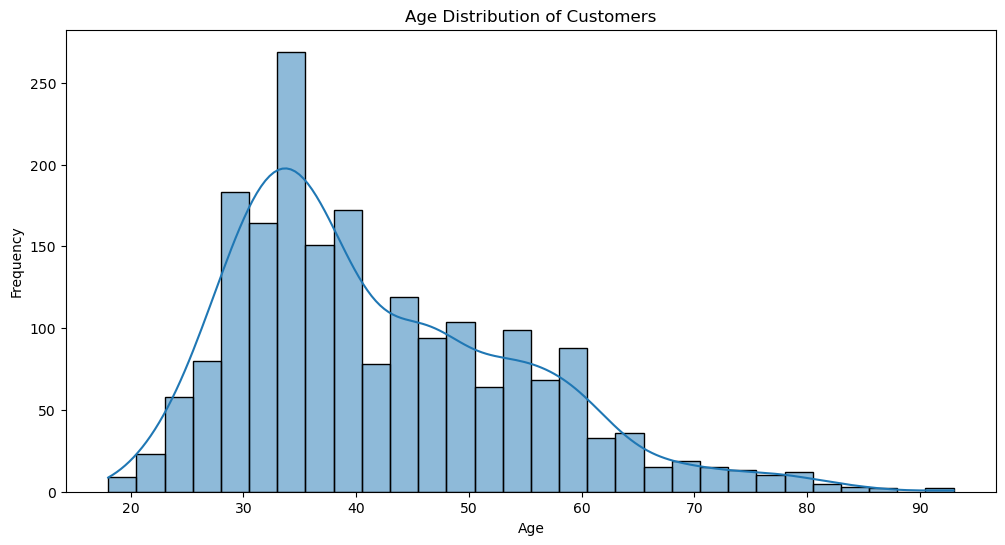

In [28]:
#Using two different plotting techniques to plot the distribution of some numerical attributes
#Plot1:
plt.figure(figsize=(12, 6))
sns.histplot(bank_df['age'], bins=30, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

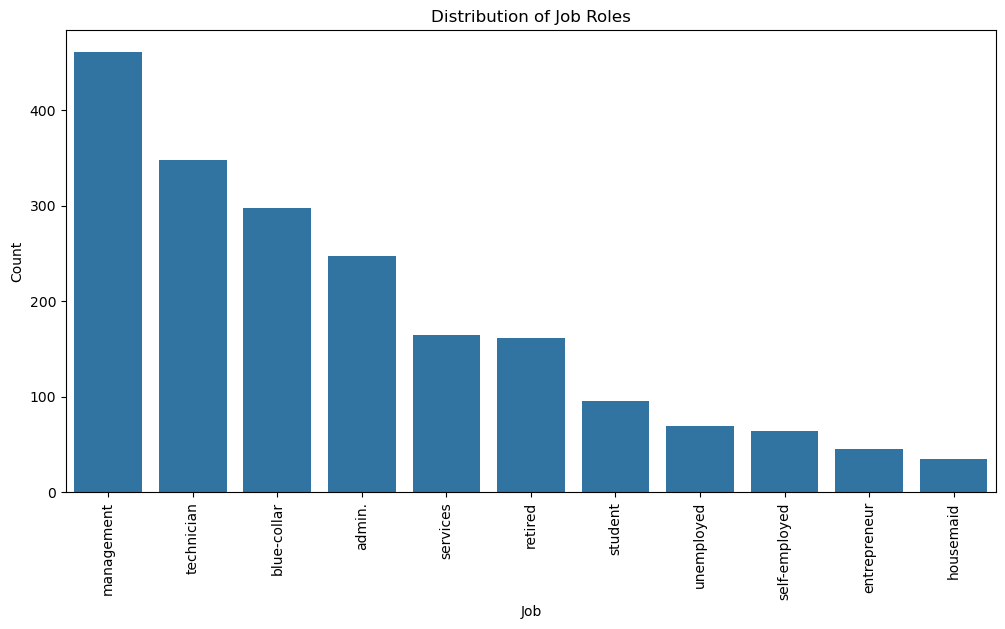

In [29]:
#Plot2
plt.figure(figsize=(12, 6))
sns.countplot(x=bank_df['job'], order=bank_df['job'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Job Roles')
plt.xlabel('Job')
plt.ylabel('Count')
plt.show()

Insights from these plots:

The age distribution shows a higher concentration of younger customers, with fewer older customers.
The job distribution suggests that professions such as blue-collar and management roles are common among customers.
These distributions provide insights into which customer segments may be more engaged with the bank's services.

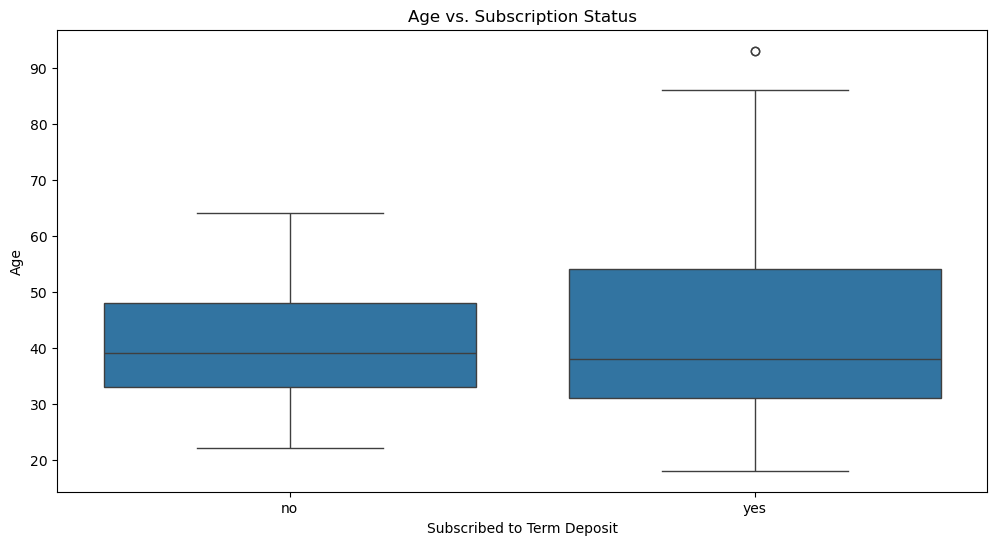

In [37]:
#Generating two plots with the combined distribution of attributes
#Plot1
plt.figure(figsize=(12, 6))
sns.boxplot(x=bank_df['subscribed'], y=bank_df['age'])
plt.title('Age vs. Subscription Status')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Age')
plt.show()

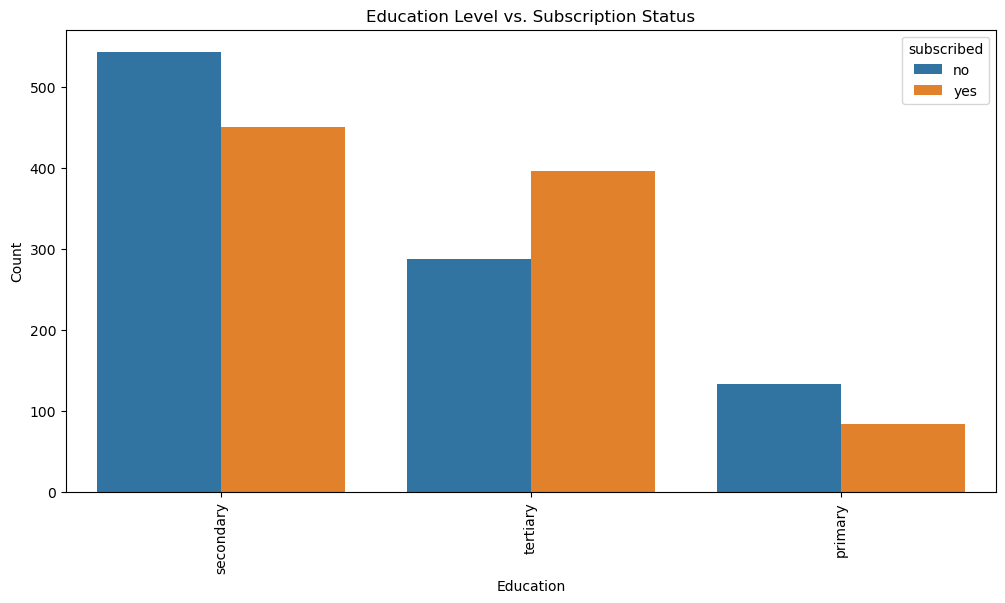

In [41]:
#Plot2
plt.figure(figsize=(12, 6))
sns.countplot(x=bank_df['education'], hue=bank_df['subscribed'], order=bank_df['education'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Education Level vs. Subscription Status')
plt.xlabel('Education')
plt.ylabel('Count')
plt.show()

The relationship between attributes:

The boxplot suggests that older customers have a higher likelihood of subscribing to a term deposit.
The eductaion-level plot indicates that customers with higher education levels may be more inclined to subscribe.
These insights can help refine marketing strategies by targeting specific age groups and education levels more effectively.

Task 2:

A. Import Python Modules and Dataset

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
#Loading the dataset
bank_df = pd.read_csv("C:\\Users\\david.sheridan\\Downloads\\bank.csv")

In [7]:
#Making a copy of the original dataset
bank_original = bank_df.copy()

B. Process and Encode the Categorical Features

In [11]:
#Checking categorical columns
categorical_cols = bank_df.select_dtypes(include=['object']).columns

In [15]:
#Encoding ordinal categorical attributes
bank_df['education'] = bank_df['education'].replace({'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3})
bank_df = bank_df.infer_objects(copy=False)

In [17]:
#One-hot encode remaining categorical attributes
bank_df = pd.get_dummies(bank_df, columns=['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'], drop_first=True)

C. Treatment of Missing Values in Numerical Columns

In [20]:
#Checking for missing values
print(bank_df.isna().sum())

age                   12
education            104
balance                0
day                    0
duration               0
campaign               0
pdays                  0
previous               0
subscribed             0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
marital_married        0
marital_single         0
default_yes            0
housing_yes            0
loan_yes               0
contact_telephone      0
month_aug              0
month_dec              0
month_feb              0
month_jan              0
month_jul              0
month_jun              0
month_mar              0
month_may              0
month_nov              0
month_oct              0
month_sep              0
poutcome_other         0
poutcome_success       0
dtype: int64


In [24]:
#Filling missing values with median
bank_df.fillna(bank_df.select_dtypes(include=['number']).median(), inplace=True)

D. Rescaling Features

In [27]:
#Identifying numerical columns
numerical_cols = bank_df.select_dtypes(include=['int64', 'float64']).columns

In [29]:
#Applying RobustScaler to numerical columns
scaler = RobustScaler()
bank_df[numerical_cols] = scaler.fit_transform(bank_df[numerical_cols])

E. Treatment of Outliers

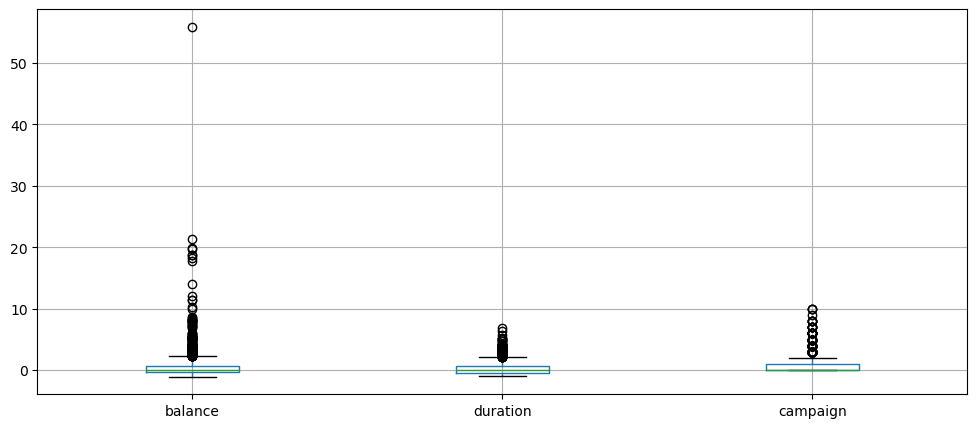

In [32]:
#Checking distribution before transformation
plt.figure(figsize=(12, 5))
bank_df.boxplot(column=['balance', 'duration', 'campaign'])
plt.show()

In [40]:
#Applying log transformation to skewed attributes
bank_df['balance'] = np.log1p(bank_df['balance'].clip(lower=0))
bank_df['duration'] = np.log1p(bank_df['duration'].clip(lower=0))

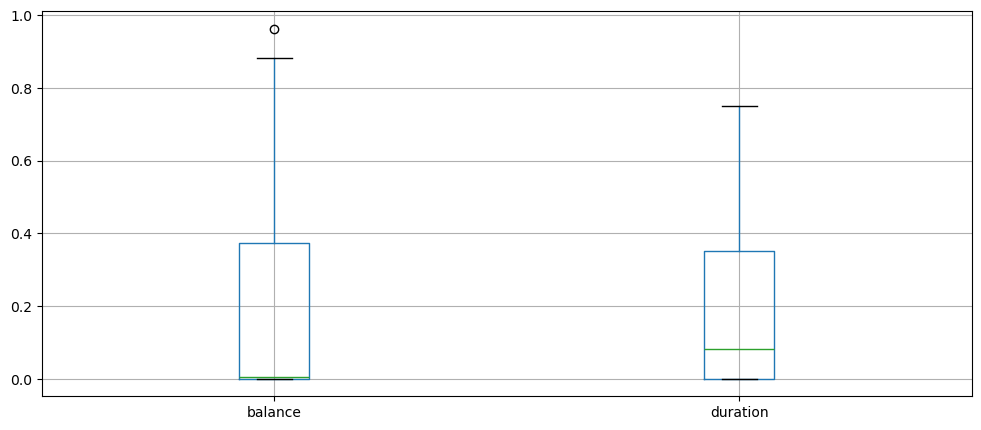

In [42]:
#Checking the distribution after transformation
plt.figure(figsize=(12, 5))
bank_df.boxplot(column=['balance', 'duration'])
plt.show()

F. Creation of Derived Features

In [44]:
#Creating a new feature: total_campaign_interactions
bank_df['total_campaign_interactions'] = bank_df['campaign'] + bank_df['previous']

G. Save the Prepared Dataset

In [51]:
#Saving the prepared dataset
bank_df.to_csv('bank_prepared.csv', index=False)
print("Data preparation complete. Saved as 'bank_prepared.csv'.")

Data preparation complete. Saved as 'bank_prepared.csv'.
